---
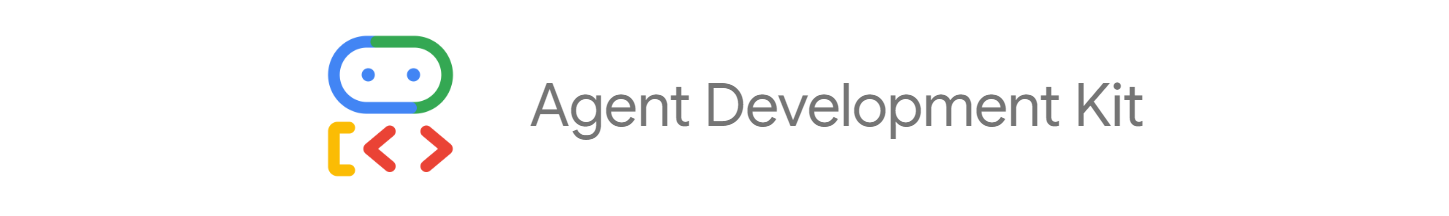

---

# Artifacts

In ADK, **Artifacts** represent a crucial mechanism for managing named, versioned binary data associated either with a specific user interaction session or persistently with a user across multiple sessions. They allow your agents and tools to handle data beyond simple text strings, enabling richer interactions involving files, images, audio, and other binary formats.

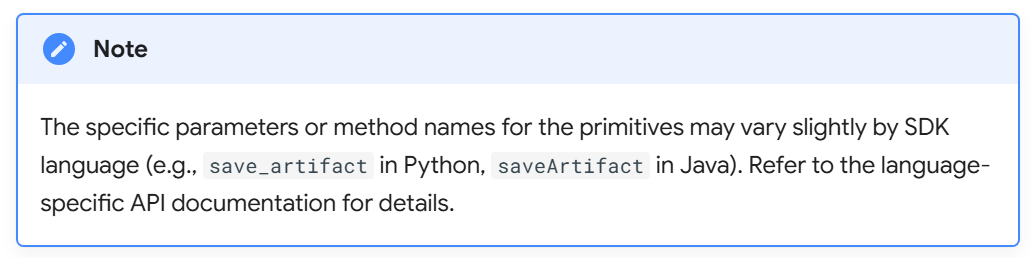

---

## What are Artifacts?
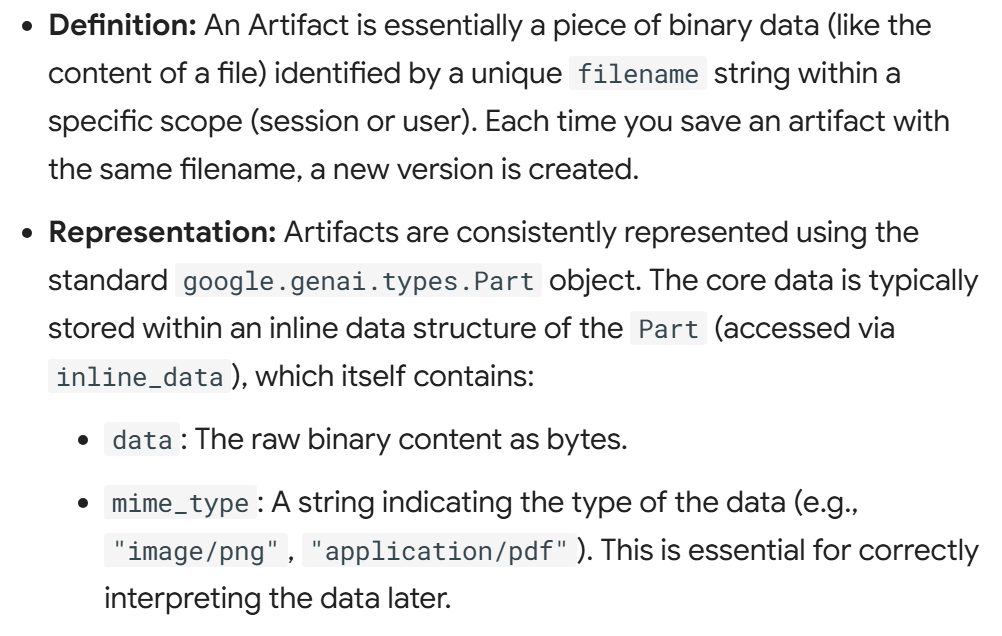

```Python
# Example of how an artifact might be represented as a types.Part
import google.genai.types as types

# Assume 'image_bytes' contains the binary data of a PNG image
image_bytes = b'\x89PNG\r\n\x1a\n...' # Placeholder for actual image bytes

image_artifact = types.Part(
    inline_data=types.Blob(
        mime_type="image/png",
        data=image_bytes
    )
)

# You can also use the convenience constructor:
# image_artifact_alt = types.Part.from_bytes(data=image_bytes, mime_type="image/png")

print(f"Artifact MIME Type: {image_artifact.inline_data.mime_type}")
print(f"Artifact Data (first 10 bytes): {image_artifact.inline_data.data[:10]}...")
```

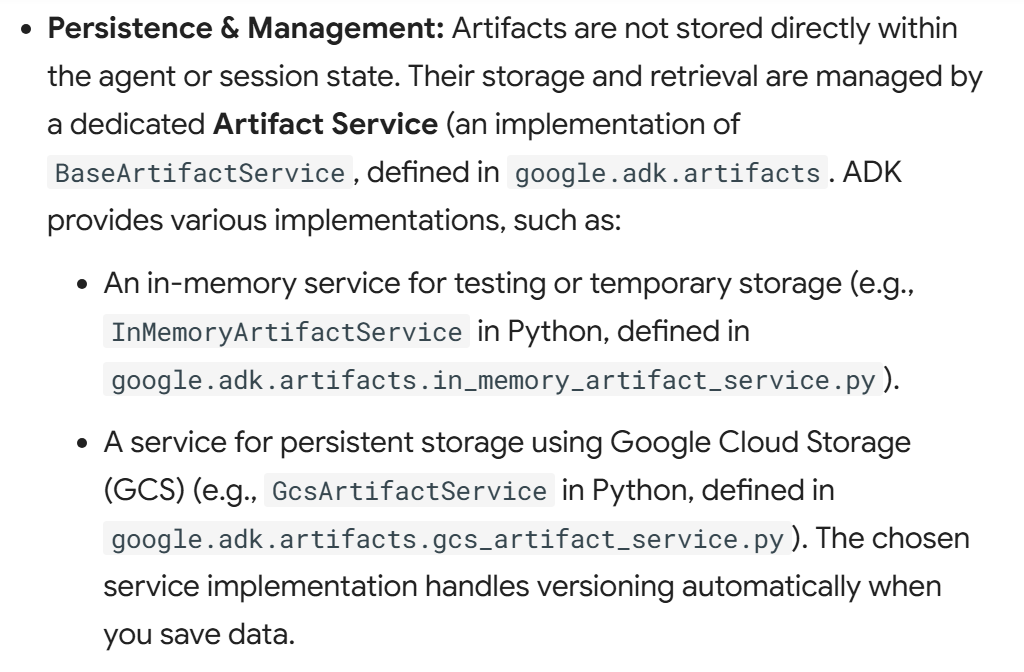

----

## Why Use Artifacts?
While session `state` is suitable for storing small pieces of configuration or conversational context (like strings, numbers, booleans, or small dictionaries/lists), Artifacts are designed for scenarios involving binary or large data:

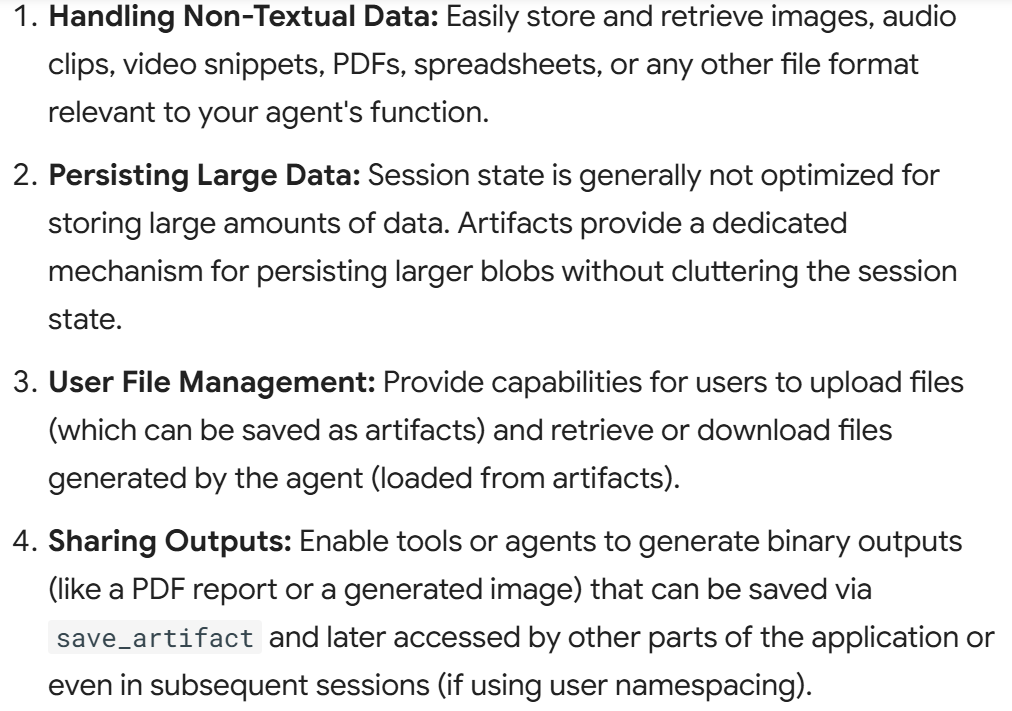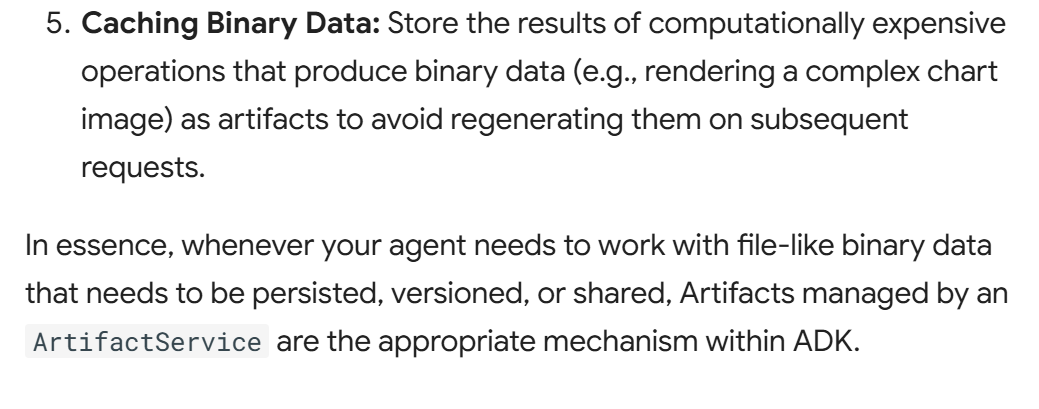

---

## Common Use Cases
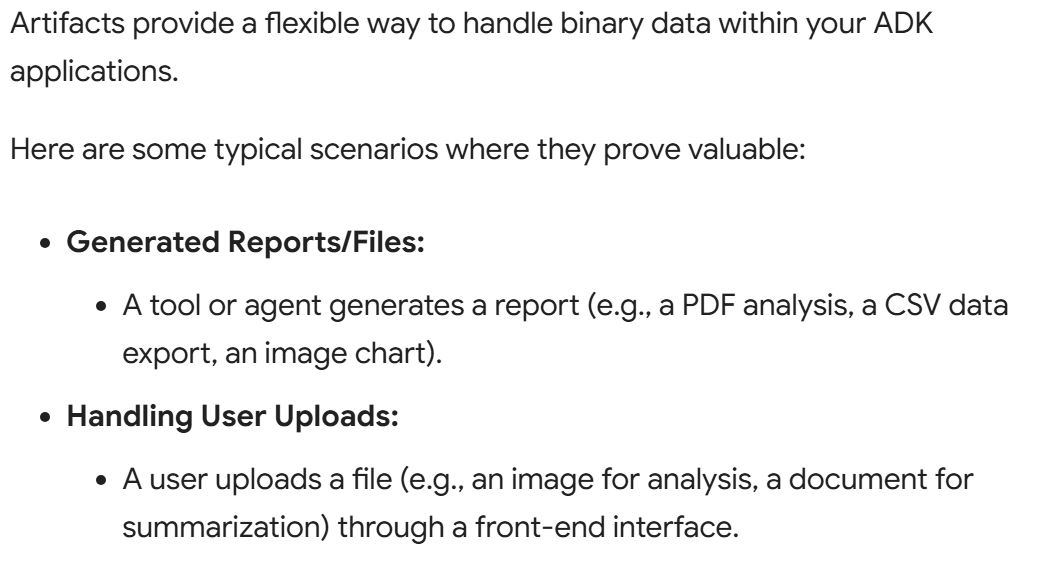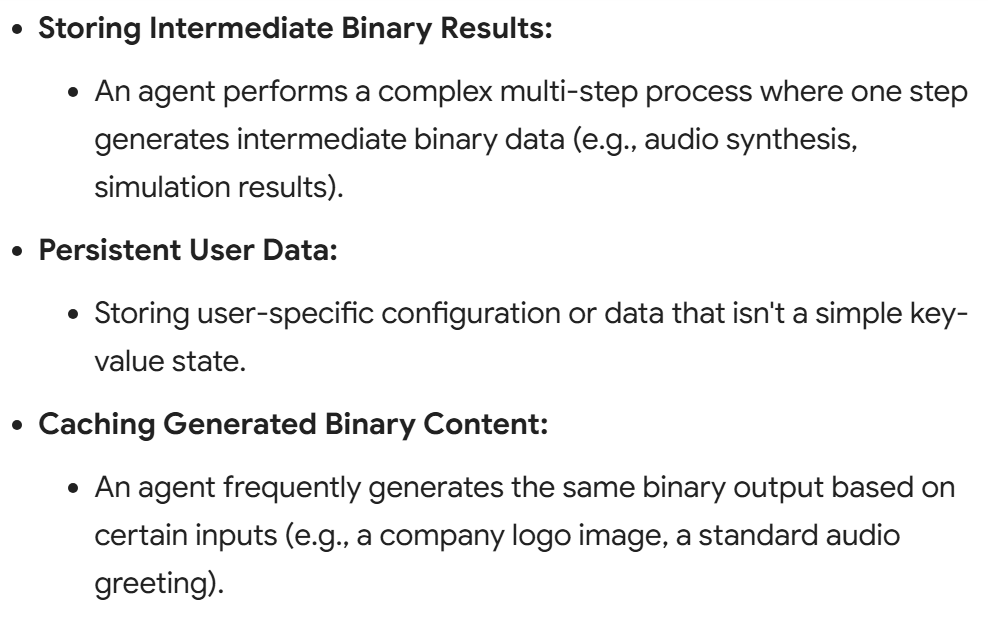

---

## Core Concepts
Understanding artifacts involves grasping a few key components: the service that manages them, the data structure used to hold them, and how they are identified and versioned.

### Artifact Service (`BaseArtifactService`)
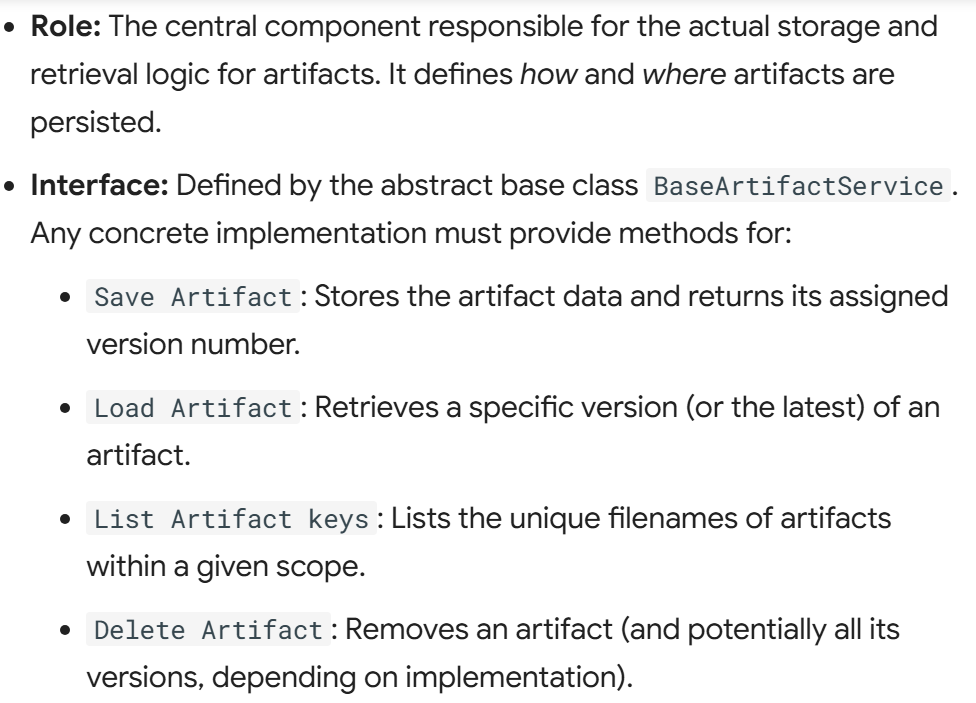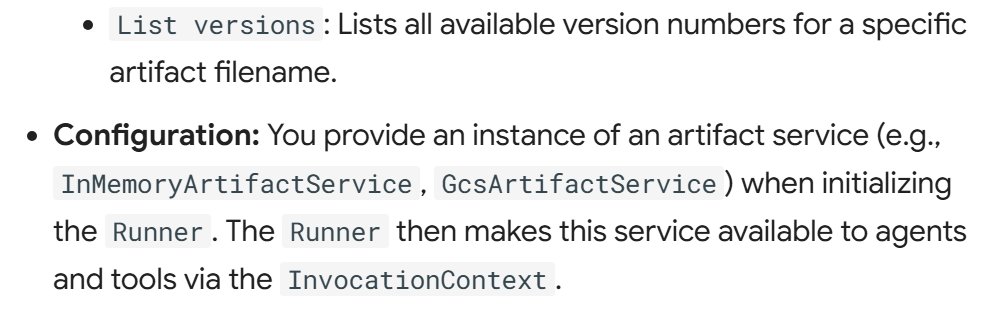

```Python
from google.adk.runners import Runner
from google.adk.artifacts import InMemoryArtifactService # Or GcsArtifactService
from google.adk.agents import LlmAgent # Any agent
from google.adk.sessions import InMemorySessionService

# Example: Configuring the Runner with an Artifact Service
my_agent = LlmAgent(name="artifact_user_agent", model="gemini-2.0-flash")
artifact_service = InMemoryArtifactService() # Choose an implementation
session_service = InMemorySessionService()

runner = Runner(
    agent=my_agent,
    app_name="my_artifact_app",
    session_service=session_service,
    artifact_service=artifact_service # Provide the service instance here
)
# Now, contexts within runs managed by this runner can use artifact methods
```

### Artifact Data
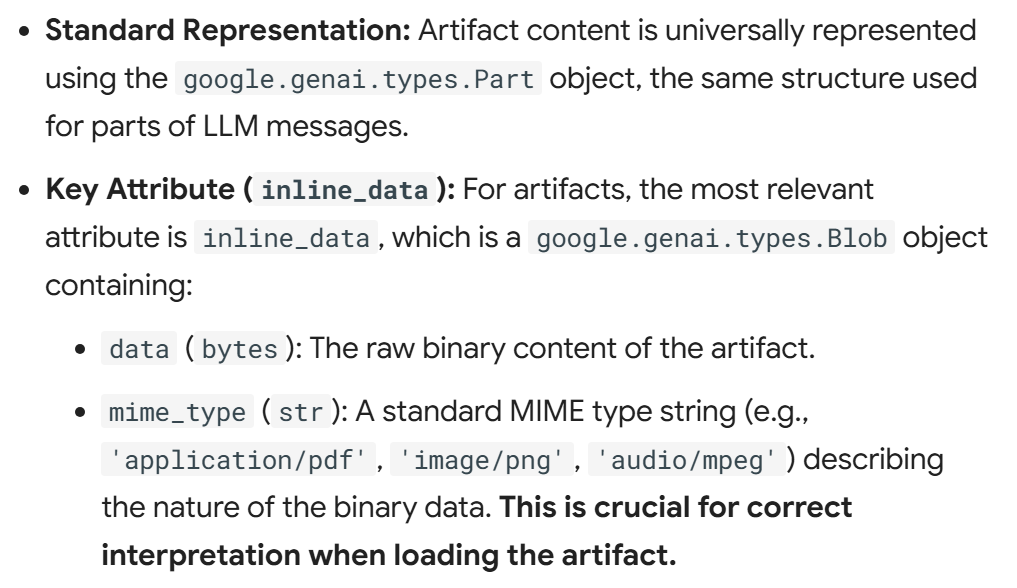

```Python
import google.genai.types as types

# Example: Creating an artifact Part from raw bytes
pdf_bytes = b'%PDF-1.4...' # Your raw PDF data
pdf_mime_type = "application/pdf"

# Using the constructor
pdf_artifact_py = types.Part(
    inline_data=types.Blob(data=pdf_bytes, mime_type=pdf_mime_type)
)

# Using the convenience class method (equivalent)
pdf_artifact_alt_py = types.Part.from_bytes(data=pdf_bytes, mime_type=pdf_mime_type)

print(f"Created Python artifact with MIME type: {pdf_artifact_py.inline_data.mime_type}")
```

### Filename
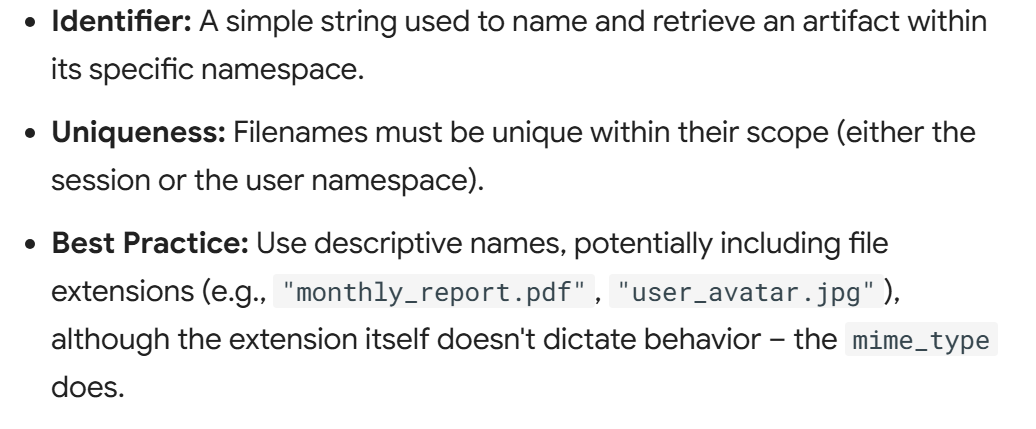

### Versioning
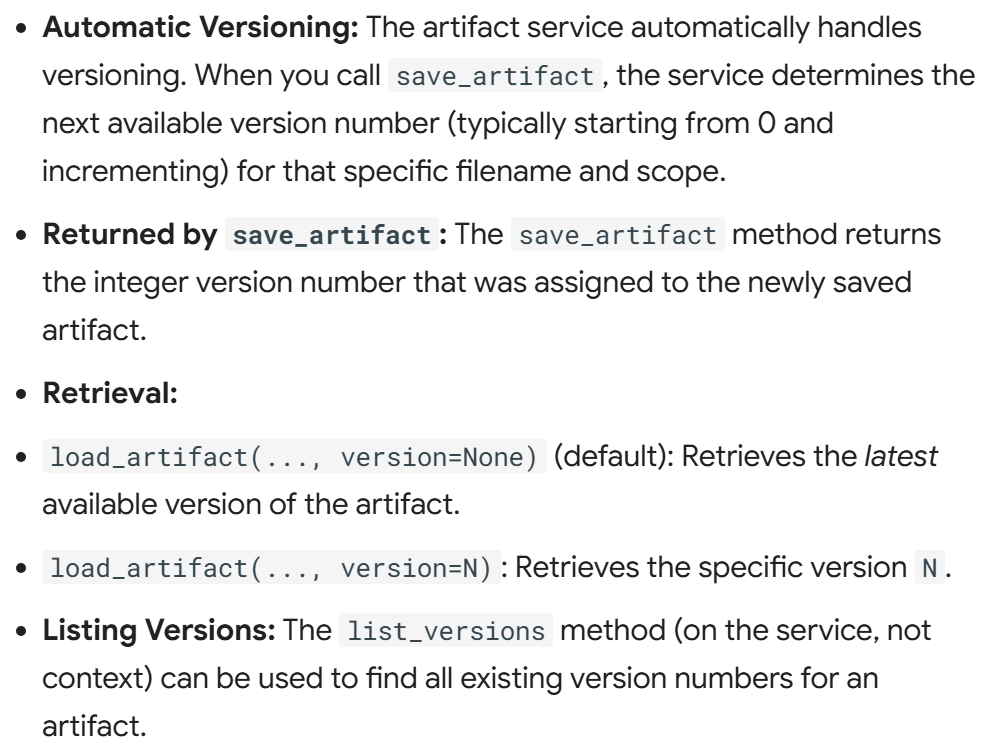

### Namespacing (Session vs. User)
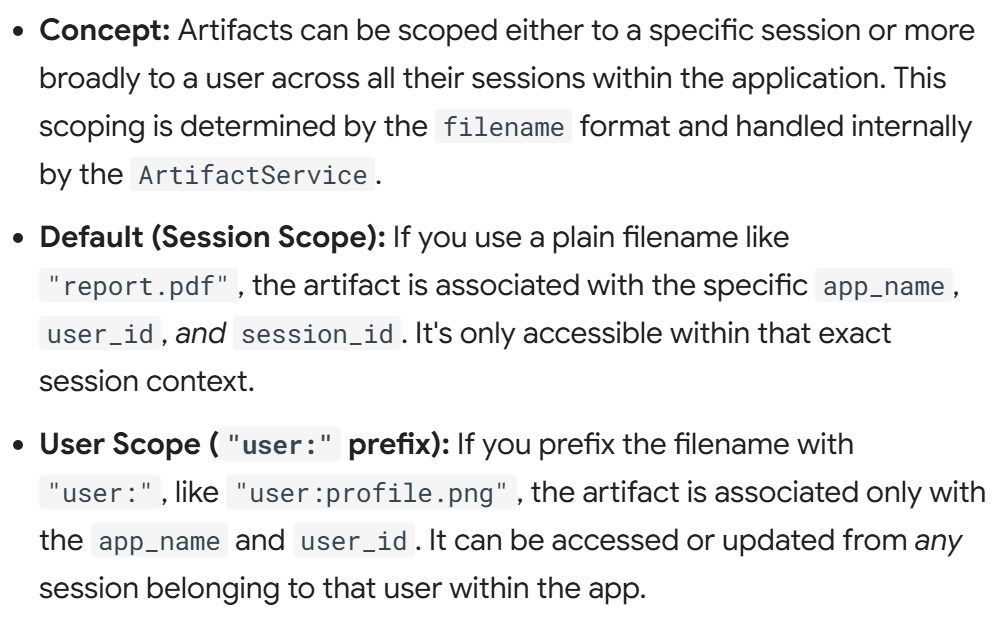

```Python
# Example illustrating namespace difference (conceptual)

# Session-specific artifact filename
session_report_filename = "summary.txt"

# User-specific artifact filename
user_config_filename = "user:settings.json"

# When saving 'summary.txt' via context.save_artifact,
# it's tied to the current app_name, user_id, and session_id.

# When saving 'user:settings.json' via context.save_artifact,
# the ArtifactService implementation should recognize the "user:" prefix
# and scope it to app_name and user_id, making it accessible across sessions for that user.
```

> These core concepts work together to provide a flexible system for managing binary data within the ADK framework.

---

## Interacting with Artifacts (via Context Objects)
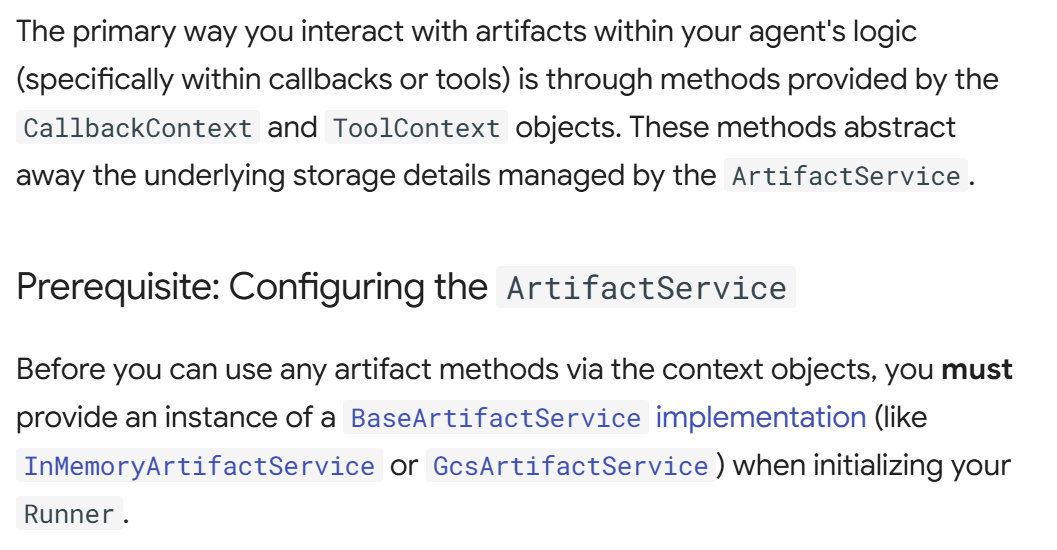

#### `In Python, you provide this instance when initializing your Runner.`

```Python
from google.adk.runners import Runner
from google.adk.artifacts import InMemoryArtifactService # Or GcsArtifactService
from google.adk.agents import LlmAgent
from google.adk.sessions import InMemorySessionService

# Your agent definition
agent = LlmAgent(name="my_agent", model="gemini-2.0-flash")

# Instantiate the desired artifact service
artifact_service = InMemoryArtifactService()

# Provide it to the Runner
runner = Runner(
    agent=agent,
    app_name="artifact_app",
    session_service=InMemorySessionService(),
    artifact_service=artifact_service # Service must be provided here
)
```

> If no artifact_service is configured in the InvocationContext (which happens if it's not passed to the Runner), calling save_artifact, load_artifact, or list_artifacts on the context objects will raise a ValueError.

### Accessing Methods
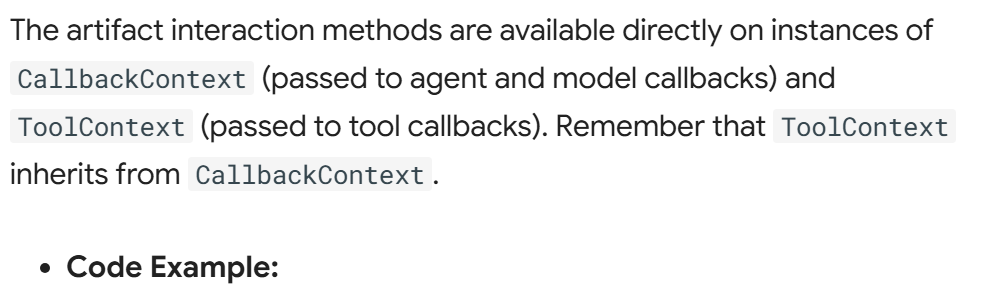

```Python
import google.genai.types as types
from google.adk.agents.callback_context import CallbackContext # Or ToolContext

async def save_generated_report_py(context: CallbackContext, report_bytes: bytes):
    """Saves generated PDF report bytes as an artifact."""
    report_artifact = types.Part.from_data(
        data=report_bytes,
        mime_type="application/pdf"
    )
    filename = "generated_report.pdf"

    try:
        version = await context.save_artifact(filename=filename, artifact=report_artifact)
        print(f"Successfully saved Python artifact '{filename}' as version {version}.")
        # The event generated after this callback will contain:
        # event.actions.artifact_delta == {"generated_report.pdf": version}
    except ValueError as e:
        print(f"Error saving Python artifact: {e}. Is ArtifactService configured in Runner?")
    except Exception as e:
        # Handle potential storage errors (e.g., GCS permissions)
        print(f"An unexpected error occurred during Python artifact save: {e}")

# --- Example Usage Concept (Python) ---
# async def main_py():
#   callback_context: CallbackContext = ... # obtain context
#   report_data = b'...' # Assume this holds the PDF bytes
#   await save_generated_report_py(callback_context, report_data)
```

### Loading Artifacts
- **Code Example:**

```Python
import google.genai.types as types
from google.adk.agents.callback_context import CallbackContext # Or ToolContext

async def process_latest_report_py(context: CallbackContext):
    """Loads the latest report artifact and processes its data."""
    filename = "generated_report.pdf"
    try:
        # Load the latest version
        report_artifact = await context.load_artifact(filename=filename)

        if report_artifact and report_artifact.inline_data:
            print(f"Successfully loaded latest Python artifact '{filename}'.")
            print(f"MIME Type: {report_artifact.inline_data.mime_type}")
            # Process the report_artifact.inline_data.data (bytes)
            pdf_bytes = report_artifact.inline_data.data
            print(f"Report size: {len(pdf_bytes)} bytes.")
            # ... further processing ...
        else:
            print(f"Python artifact '{filename}' not found.")

        # Example: Load a specific version (if version 0 exists)
        # specific_version_artifact = await context.load_artifact(filename=filename, version=0)
        # if specific_version_artifact:
        #     print(f"Loaded version 0 of '{filename}'.")

    except ValueError as e:
        print(f"Error loading Python artifact: {e}. Is ArtifactService configured?")
    except Exception as e:
        # Handle potential storage errors
        print(f"An unexpected error occurred during Python artifact load: {e}")

# --- Example Usage Concept (Python) ---
# async def main_py():
#   callback_context: CallbackContext = ... # obtain context
#   await process_latest_report_py(callback_context)
```

### Listing Artifact Filenames
- **Code Example:**

```Python
from google.adk.tools.tool_context import ToolContext

def list_user_files_py(tool_context: ToolContext) -> str:
    """Tool to list available artifacts for the user."""
    try:
        available_files = await tool_context.list_artifacts()
        if not available_files:
            return "You have no saved artifacts."
        else:
            # Format the list for the user/LLM
            file_list_str = "\n".join([f"- {fname}" for fname in available_files])
            return f"Here are your available Python artifacts:\n{file_list_str}"
    except ValueError as e:
        print(f"Error listing Python artifacts: {e}. Is ArtifactService configured?")
        return "Error: Could not list Python artifacts."
    except Exception as e:
        print(f"An unexpected error occurred during Python artifact list: {e}")
        return "Error: An unexpected error occurred while listing Python artifacts."

# This function would typically be wrapped in a FunctionTool
# from google.adk.tools import FunctionTool
# list_files_tool = FunctionTool(func=list_user_files_py)
```

> These methods for saving, loading, and listing provide a convenient and consistent way to manage binary data persistence within ADK, whether using Python's context objects or directly interacting with the BaseArtifactService in Java, regardless of the chosen backend storage implementation.

----

## Available Implementations
ADK provides concrete implementations of the BaseArtifactService interface, offering different storage backends suitable for various development stages and deployment needs. These implementations handle the details of storing, versioning, and retrieving artifact data based on the app_name, user_id, session_id, and filename (including the user: namespace prefix).

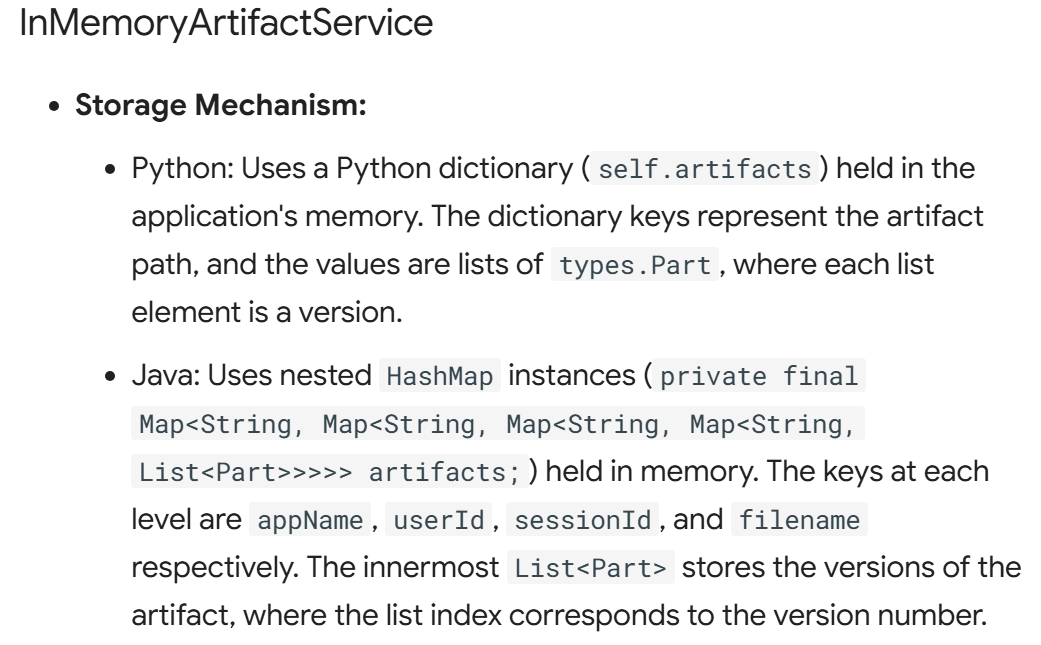 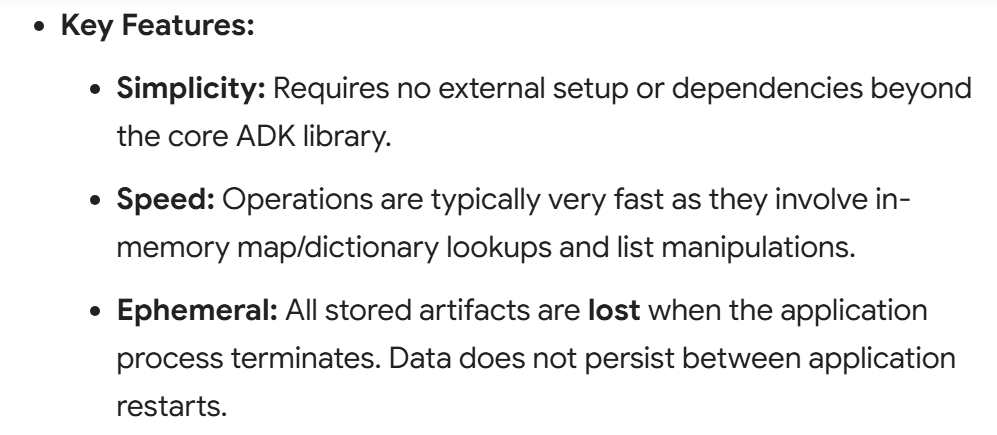 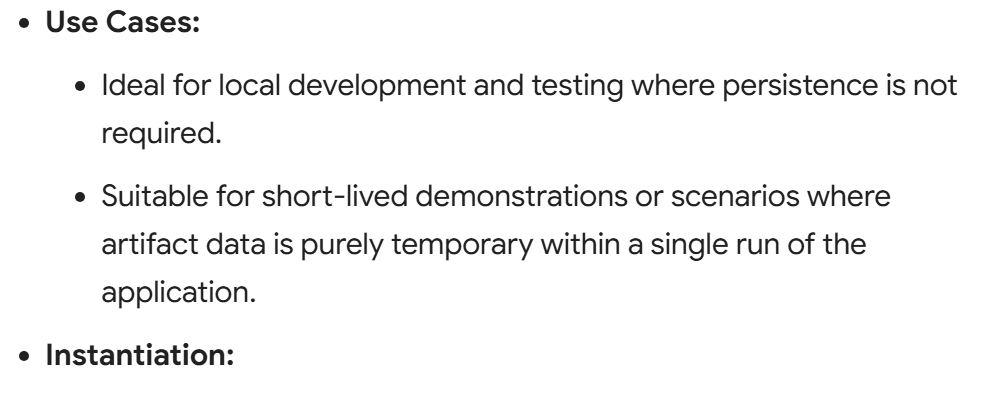

```Python
from google.adk.artifacts import InMemoryArtifactService

# Simply instantiate the class
in_memory_service_py = InMemoryArtifactService()

# Then pass it to the Runner
# runner = Runner(..., artifact_service=in_memory_service_py)
```

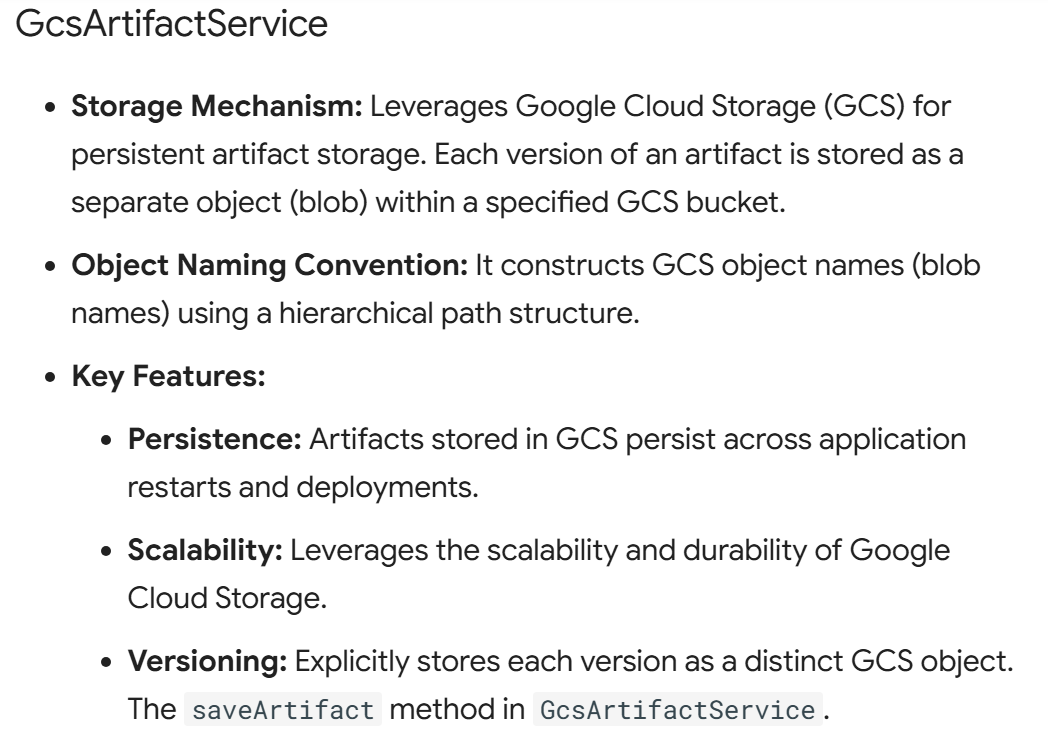 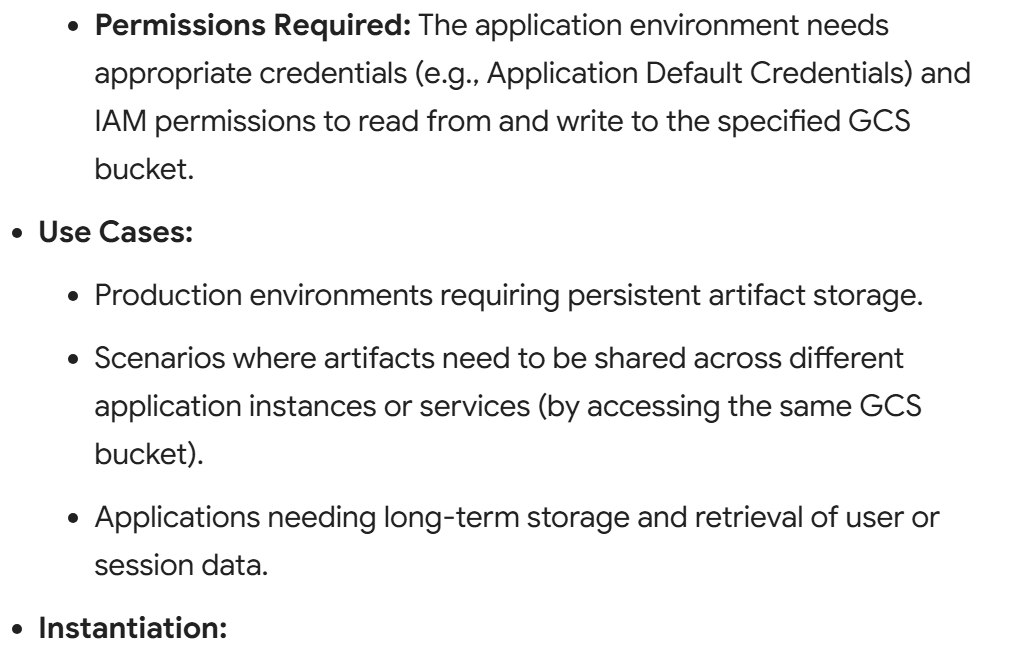 

```Python
from google.adk.artifacts import GcsArtifactService

# Specify the GCS bucket name
gcs_bucket_name_py = "your-gcs-bucket-for-adk-artifacts" # Replace with your bucket name

try:
    gcs_service_py = GcsArtifactService(bucket_name=gcs_bucket_name_py)
    print(f"Python GcsArtifactService initialized for bucket: {gcs_bucket_name_py}")
    # Ensure your environment has credentials to access this bucket.
    # e.g., via Application Default Credentials (ADC)

    # Then pass it to the Runner
    # runner = Runner(..., artifact_service=gcs_service_py)

except Exception as e:
    # Catch potential errors during GCS client initialization (e.g., auth issues)
    print(f"Error initializing Python GcsArtifactService: {e}")
    # Handle the error appropriately - maybe fall back to InMemory or raise
```

> Choosing the appropriate ArtifactService implementation depends on your application's requirements for data persistence, scalability, and operational environment.

----

## Best Practics
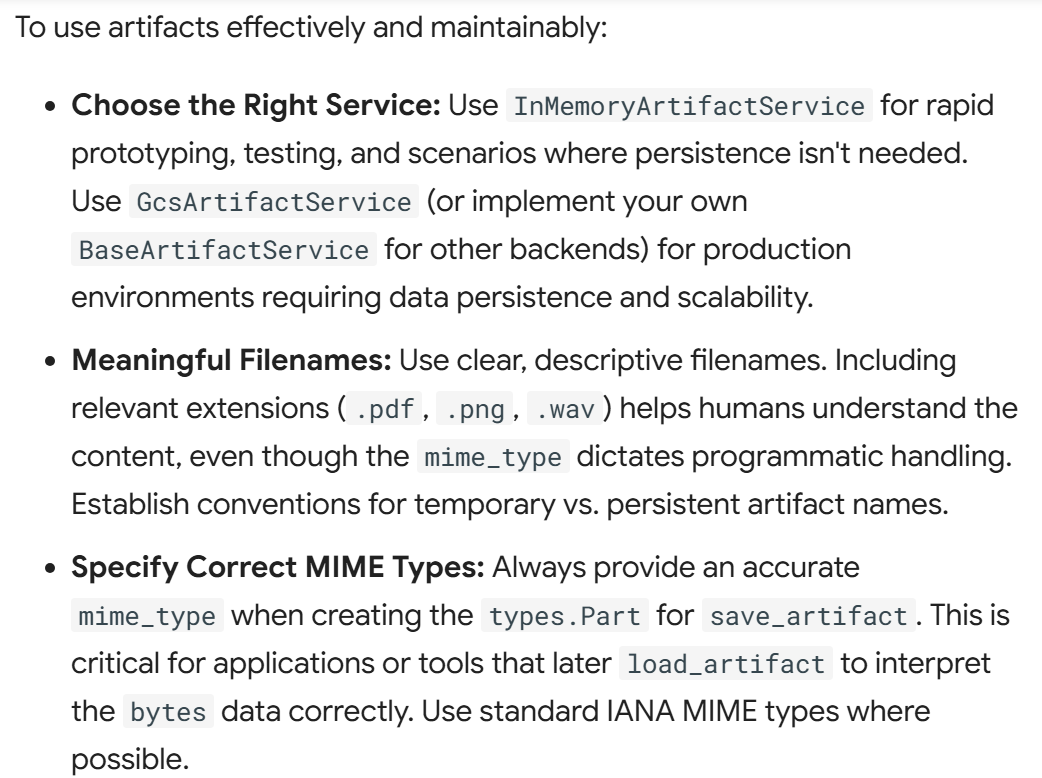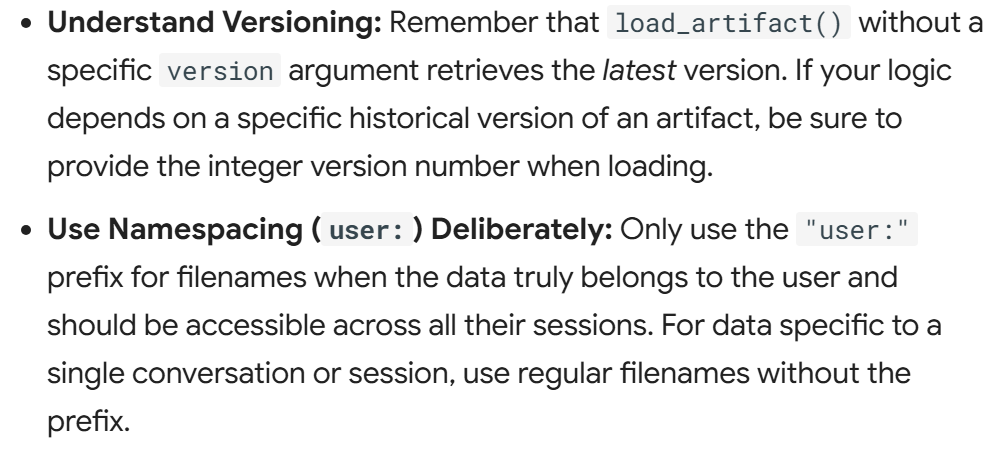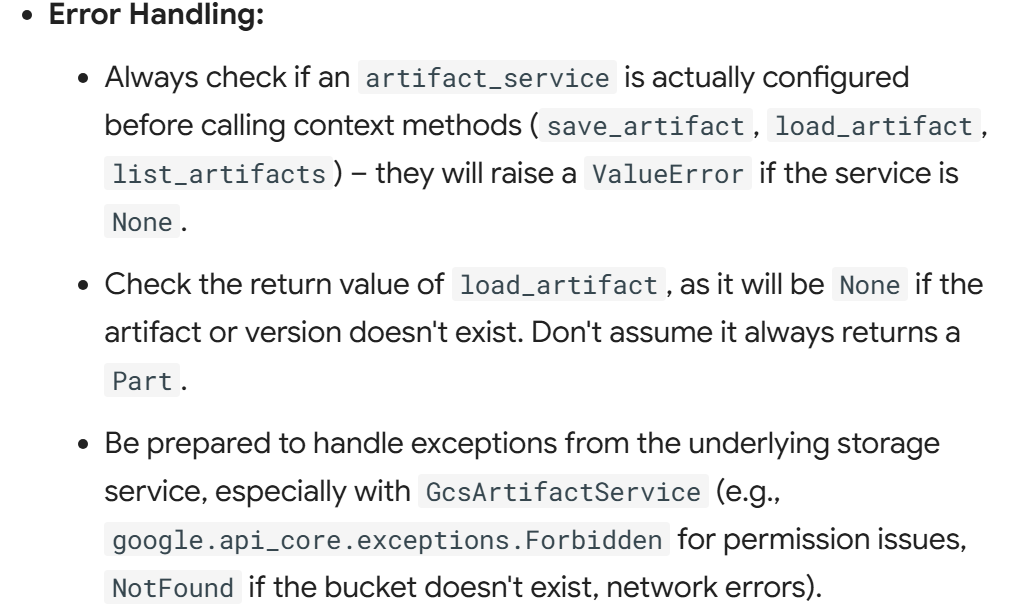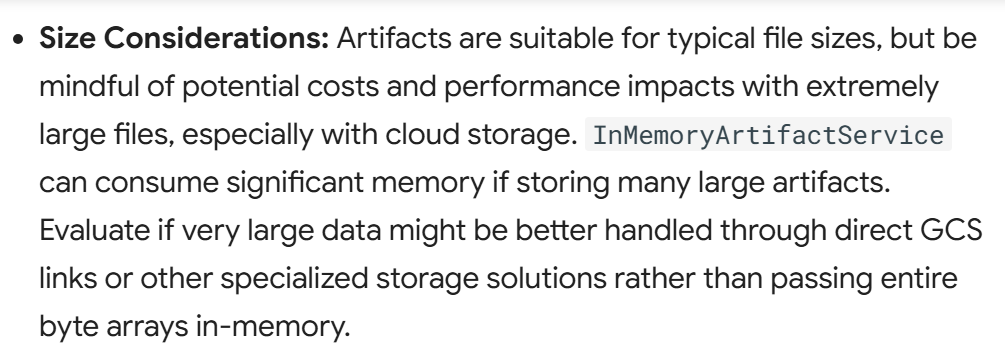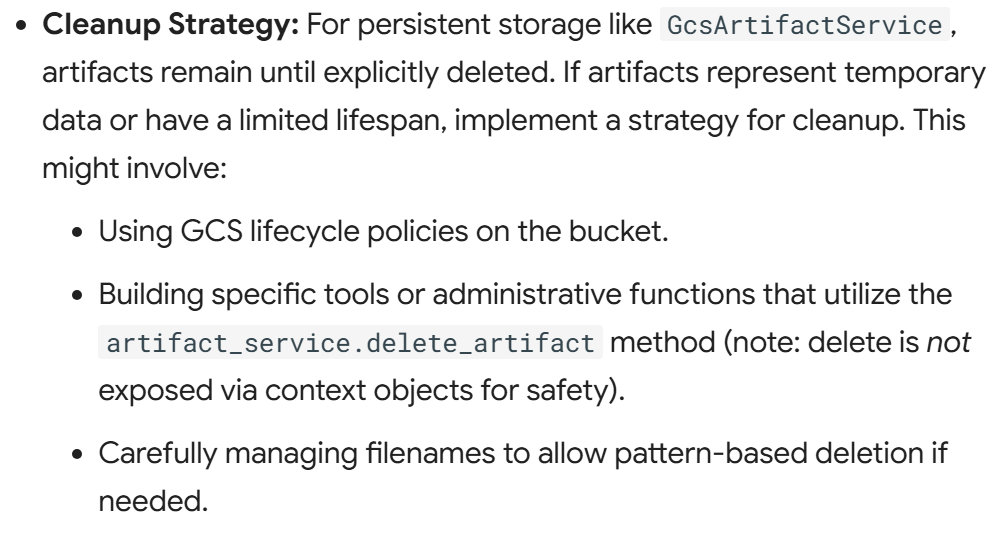

---